Estudiante: Elmer Hernán Barquero Chaves C10896

# Parte I: Espectro y Reconstrucción usando FFT

La función con la que se va a trabajar es:

$$f(t) = sgn[sin(2\pi f t)] $$

In [38]:
import numpy as np
import matplotlib.pyplot as plt

In [39]:
freq = 1 # Frecuencia de oscilacion
t = np.linspace(0.0,1/freq,1000)
def math_function(frecuencia, tiempo):
	return np.sign(np.sin(2*np.pi*frecuencia*tiempo))

## Gráfico de la  función

Text(0.5, 1.0, 'Signal')

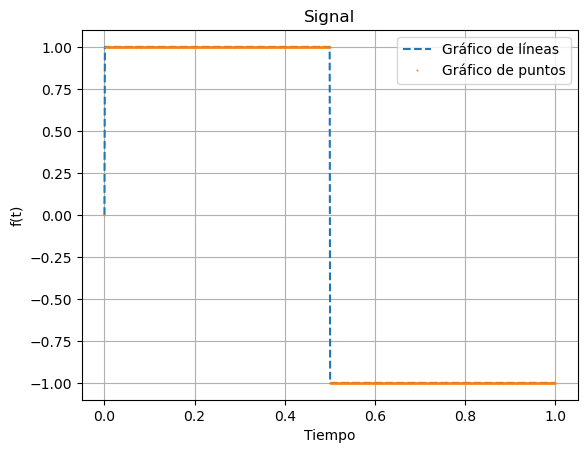

In [40]:
fig, ax = plt.subplots(1,1)
ax.plot(t, math_function(freq, t),'--', label = "Gráfico de líneas")
ax.plot(t, math_function(freq, t),'.', ms = 1, label = "Gráfico de puntos")

ax.grid()
ax.legend()

ax.set_xlabel("Tiempo")
ax.set_ylabel(r"f(t)")

ax.set_title("Signal")

## FFT en un solo período y con N = 1000

In [41]:
FFT_math_func = np.fft.fft(math_function(freq,t), norm= "forward")

freq_math_func = np.fft.fftfreq(len(FFT_math_func), d=t[1]-t[0])

## Gráfico del Espectro

Text(0.5, 1.0, 'Fast Fourier Transformation of the signal')

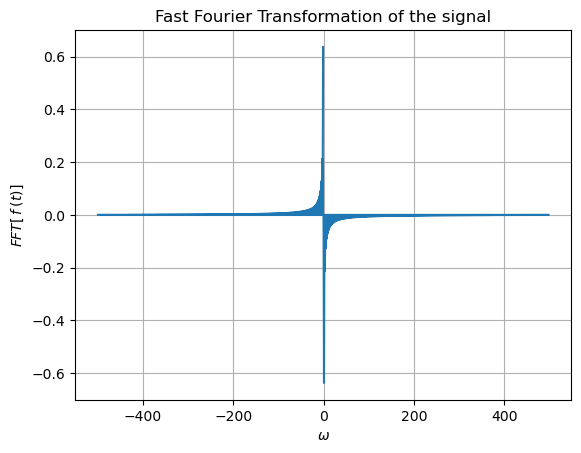

In [42]:
fig, ax = plt.subplots(1,1)
ax.plot(freq_math_func,np.imag(FFT_math_func),'-')

ax.grid()

ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"$FFT[\:f \: (t)]$")
ax.set_title("Fast Fourier Transformation of the signal")

#ax.set_xlim(-20,20)

## Conclusiones del modo de oscilación

Se observa secciones positivas y  negativas en el gráfico debido a que la señal cuadrada utilizada presenta simetría respecto al eje X.

Como es de esperarse,los picos postivos de la gráfica, respresentan los **modos de oscilación** de la señal y corresponden a frecuencias impares del espectro. Dichos picos son los **armónicos** de la señal y el conjunto de estos describen el comportamiendo de la señal estudiada.

## Reconstrucción de la señal original

In [43]:
# Función para reconstruir: Fórmula explícita de la DFT inversa

def reconstruct_signal(c_k, k, N):
    n = np.arange(N)  
    y_n = np.sum(c_k[:k] * np.exp(1j * 2 * np.pi * np.outer(n, np.arange(k)) / N), axis=1)
    return np.real(y_n)  # Se toma la parte real

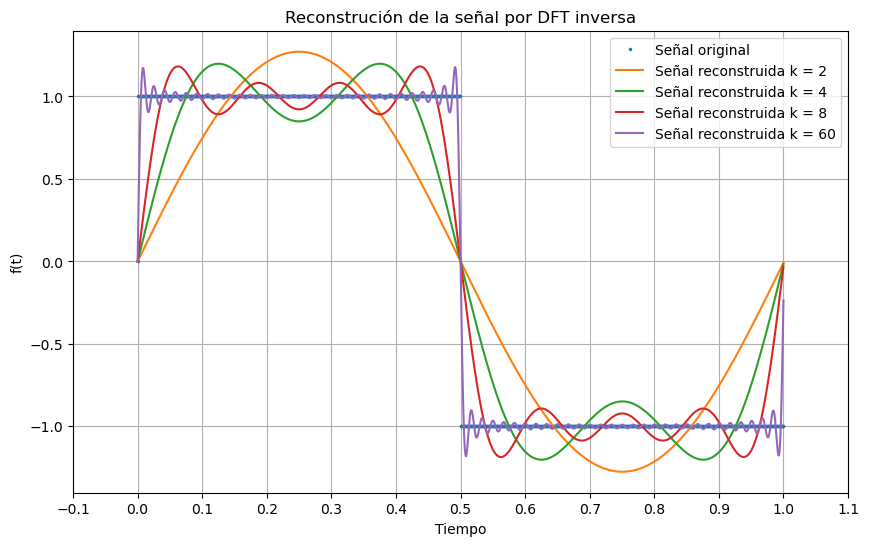

In [44]:
# DFT
FFT_mf_half = np.copy(FFT_math_func)   # Deep copy
FFT_mf_half[freq_math_func < 0]              
FFT_mf_half *= 2 

# Valores de k para las aproximaciones
k_values = [2, 4, 8, 60]


fig, ax =plt.subplots(1,1, figsize = (10,6))
ax.plot(t, math_function(freq, t),'.', ms = 3, label = "Señal original")

for i in k_values:
    ax.plot(t, reconstruct_signal(FFT_mf_half,i,1000), label= f"Señal reconstruida k = {i}")

ax.set_title("Reconstrución de la señal por DFT inversa")
ax.set_xlabel("Tiempo")
ax.set_xticks(np.arange(-0.1,1.1,0.1))

ax.set_ylabel(r"f(t)")
ax.legend()
ax.grid()

## Conclusiones de la reconstrucción

* Valores de k pequeños: Se generan aproximaciones al **comportamiento general** de la señal original, más no representan una aproximación cercana a la señal. Unicamente se muestra el comportamiendo predominante de la señal.

* Valores de k grandes: La reconstrucción de la función se aproxima bastante bien al **comportamiento real** de la señal original. No obstante, se observa la presencia fenómeno de Gibbs en la recuperación de la señal original, dado que la señal es una función discontinua y se está aproximando mediante una serie de expansión finita; el cual se podría decir que genera la mayor distorsión entre la señal original y la recuperada.


En general, la escogencia de k, produce aproximaciones menos o más precisas según la magnitud del número en cuestión, esto es así ya que se aumenta el número de términos que realizan la transformada de Fourier discreta. 

Los modos de oscilación más relevantes son los que poseen las frecuencias más cercanas a cero y por tanto los que se encuentran en las gráficas con k's más pequeños.

# Parte II: Ecuaciones Elípticas

## Código del docente

In [45]:
# Esta función toma como argumentos el tamaño lineal de la grilla cuadrada,
# el valor del voltaje en la sección superior de la grilla y la tolerancia de convergencia 
def jacobi_relaxation(M, V, tolerance):
    # Primero creamos los arreglos 2-dimensionales de la grilla
    # Vamos a necesitar dos según la regla de Jacobi
    # Note que usamos M+1, debido a que debemos contener la condición de frontera
    # phi contiene inicialmente los valores iniciales. Vamos a utilizar ceros.
    phi = np.zeros((M + 1, M + 1), dtype=float)
    # Ahora tenemos que colocar la condición inicial.
    # Recuerde accesos de listas en np.ndarray
    ############################################################################
    # Aquí se edita las condiciones de frontera para el problema en cuestión
    ############################################################################
    #phi[20, 20:80] = V # Placa izquierda //// Con los ejes bien (primera entrada eje x y segunda eje y)
    #phi[80, 20:80] = -1.0*V # Placa derecha
    
    phi[20:80, 20] = V # Placa izquierda //// Con el grafico bien 
    phi[20:80,80] = -1.0*V # Placa derecha

    ############################################################################
    # phiprime se necesita para la iteración
    phiprime = np.zeros((M + 1, M + 1), dtype=float)
    # Iteración de Jacobi
    delta = 1.0
    its = 0
    while delta > tolerance:
        # Calculamos la iteración
        its += 1
        for i in range(M + 1):
            for j in range(M + 1):
                # Condición de frontera
                if i == 0 or i == M or j == 0 or j == M:
                    phiprime[i, j] = phi[i, j]
                # Iteración principal
                else:
                    #COMPLETE AQUÍ
                    phiprime[i,j] = 0.25*(phi[i+1,j] + phi[i-1,j] + phi[i, j+1]  + phi[i, j-1])
        # Calculamos la diferencia máxima con respecto a los valores anteriores
        delta = np.max(np.abs(phi - phiprime))
        # Ahora intercambiamos los arreglos para la nueva iteración
        # El nuevo phi es el phiprime
        temp = phi
        phi = phiprime
        # El nuevo phiprime es el phi viejo
        phiprime = temp
        
    return phi, its

In [46]:
jacobi_vals, iterations = jacobi_relaxation(100, 1.0, 1e-5)
print(iterations)

2627


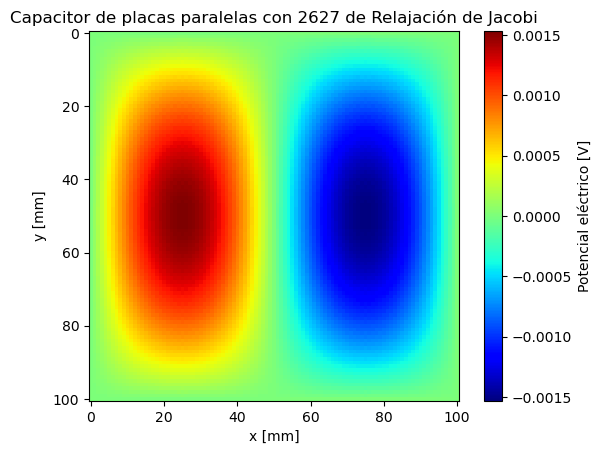

In [48]:
import matplotlib.cm as cm

fig, ax = plt.subplots()
cax = ax.imshow(jacobi_vals, cmap=cm.jet)
cbar = fig.colorbar(cax, ax=ax) 
ax.set_title(f"Capacitor de placas paralelas con {iterations} de Relajación de Jacobi")
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
cbar.set_label("Potencial eléctrico [V]")

plt.show()